#Data Boostcamp Homework3
## This jupyter notebook is done by Weiyi Lu

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
path = '/content/drive/MyDrive/Data_Bootcamp/Homework/Homework3/data'

In [7]:
app_data = pd.read_csv(path + '/application_data.csv')
prev_data = pd.read_csv(path + '/previous_application.csv')
columns_desc = pd.read_excel(path + '/columns_description.xlsx')

# Part1: analyze application_data.csv

## exploration

In [ ]:
app_data['TARGET'].value_counts(normalize=True)

,proportion
TARGET,
0,0.919271
1,0.080729


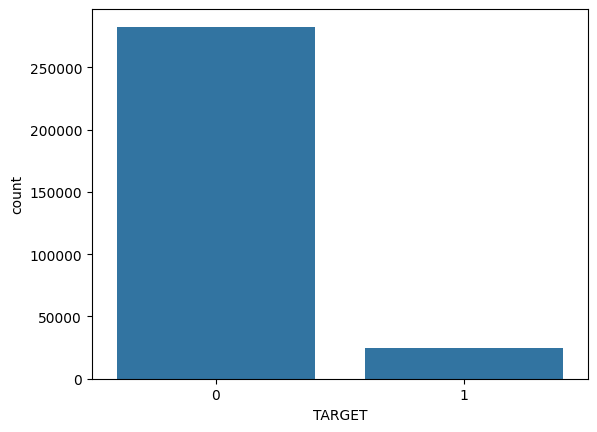

In [10]:
sns.countplot(x='TARGET', data=app_data)
plt.show()

Approximately 8% of customers experienced payment difficulties. Approximately 92% of customers made timely repayments.

In [53]:
app_data.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,AGE_YEARS,CREDIT_INCOME_RATIO,AGE_GROUP,EMP_YEARS,EMP_GROUP
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0.0,0.0,0.0,0.0,1.0,25.920548,2.007889,20-30,1.745205,0-2
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0.0,0.0,0.0,0.0,0.0,45.931507,4.790750,40-50,3.254795,2-5
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0.0,0.0,0.0,0.0,0.0,52.180822,2.000000,50-60,0.616438,0-2
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,NaN,NaN,NaN,NaN,NaN,52.068493,2.316167,50-60,8.326027,5-10
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0.0,0.0,0.0,0.0,0.0,54.608219,4.222222,50-60,8.323288,5-10


In [21]:
app_data[['TARGET', 'AMT_INCOME_TOTAL']].groupby('TARGET').median()

,AMT_INCOME_TOTAL
TARGET,
0,148500.0
1,135000.0


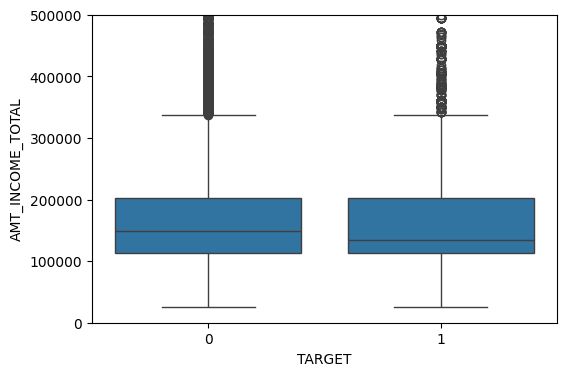

In [22]:
plt.figure(figsize=(6,4))
sns.boxplot(x='TARGET', y='AMT_INCOME_TOTAL', data=app_data)
plt.ylim(0, 500000)  #limit the upper limit to prevent extreme values
plt.show()

In [23]:
app_data[['TARGET', 'AMT_CREDIT']].groupby('TARGET').median()

,AMT_CREDIT
TARGET,
0,517788.0
1,497520.0


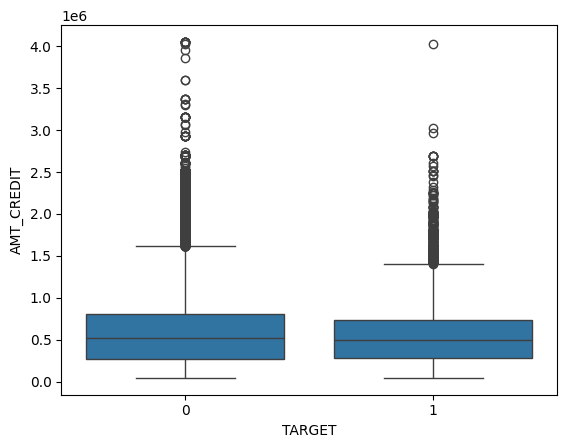

In [24]:
sns.boxplot(x='TARGET', y='AMT_CREDIT', data=app_data)
plt.show()

In [25]:
app_data['CREDIT_INCOME_RATIO'] = app_data['AMT_CREDIT'] / app_data['AMT_INCOME_TOTAL']
app_data[['TARGET', 'CREDIT_INCOME_RATIO']].groupby('TARGET').median()

,CREDIT_INCOME_RATIO
TARGET,
0,3.266653
1,3.253143


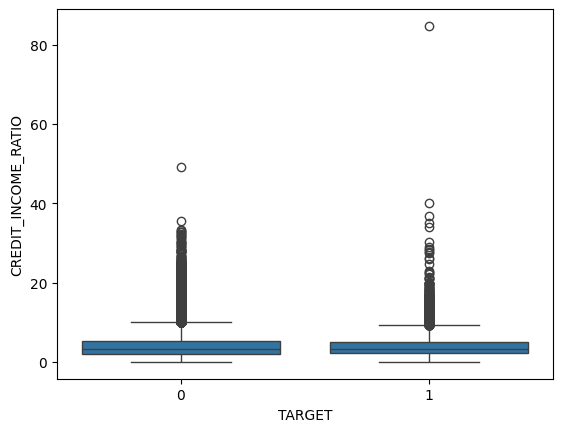

In [27]:
sns.boxplot(x='TARGET', y='CREDIT_INCOME_RATIO', data=app_data)
plt.show()

The graphs above show that Amount variables may not be the primary driver.

## Age

In [ ]:
app_data[['TARGET', 'DAYS_BIRTH']].groupby('TARGET').median()

,DAYS_BIRTH
TARGET,
0,-15877.0
1,-14282.0


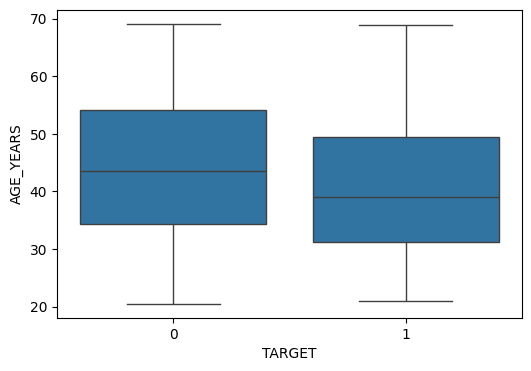

In [18]:
app_data['AGE_YEARS'] = app_data['DAYS_BIRTH'] / -365
plt.figure(figsize=(6,4))
sns.boxplot(x='TARGET', y='AGE_YEARS', data=app_data)
plt.show()


In [28]:
app_data['AGE_GROUP'] = pd.cut(
    app_data['AGE_YEARS'],
    bins=[20,30,40,50,60,70],
    labels=['20-30','30-40','40-50','50-60','60-70']
)

age_default = app_data.groupby('AGE_GROUP')['TARGET'].mean()
age_default


/tmp/ipython-input-3893860444.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_default = app_data.groupby('AGE_GROUP')['TARGET'].mean()


,TARGET
AGE_GROUP,
20-30,0.114569
30-40,0.095835
40-50,0.076508
50-60,0.061297
60-70,0.049214


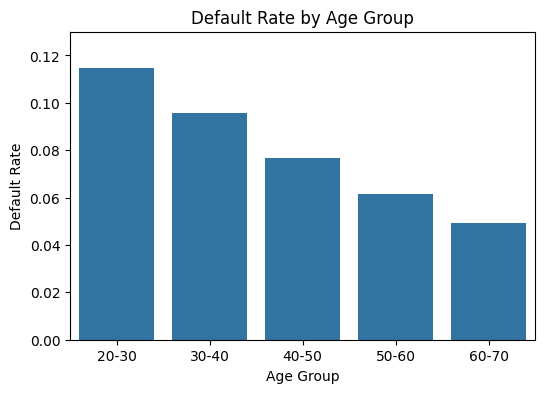

In [29]:
plt.figure(figsize=(6,4))
sns.barplot(x=age_default.index, y=age_default.values)

plt.ylabel("Default Rate")
plt.xlabel("Age Group")
plt.title("Default Rate by Age Group")
plt.ylim(0, 0.13)
plt.show()

Younger applicants (especially 20–30 age group) exhibit significantly higher default rates compared to older applicants. Default risk decreases consistently with age, indicating age is a strong predictor of repayment behavior.

## Years of employed

In [30]:
app_data[['TARGET','DAYS_EMPLOYED']].groupby('TARGET').median()

,DAYS_EMPLOYED
TARGET,
0,-1235.0
1,-1034.0


In [31]:
app_data['DAYS_EMPLOYED'].describe()


,DAYS_EMPLOYED
count,307511.000000
mean,63815.045904
std,141275.766519
min,-17912.000000
25%,-2760.000000
50%,-1213.000000
75%,-289.000000
max,365243.000000


In [32]:
(app_data['DAYS_EMPLOYED'] == 365243).sum()

np.int64(55374)

In [33]:
app_data['DAYS_EMPLOYED'] = app_data['DAYS_EMPLOYED'].replace(365243, np.nan)

In [34]:
app_data['DAYS_EMPLOYED'].describe()


,DAYS_EMPLOYED
count,252137.000000
mean,-2384.169325
std,2338.360162
min,-17912.000000
25%,-3175.000000
50%,-1648.000000
75%,-767.000000
max,0.000000


In [36]:
app_data['EMP_YEARS'] = app_data['DAYS_EMPLOYED'] / -365

In [37]:
app_data[['TARGET','EMP_YEARS']].groupby('TARGET').median()


,EMP_YEARS
TARGET,
0,4.632877
1,3.369863


In [38]:
app_data['EMP_GROUP'] = pd.cut(
    app_data['EMP_YEARS'],
    bins=[0,2,5,10,20,40],
    labels=['0-2','2-5','5-10','10-20','20+']
)

emp_default = app_data.groupby('EMP_GROUP')['TARGET'].mean()
emp_default


/tmp/ipython-input-3210212663.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  emp_default = app_data.groupby('EMP_GROUP')['TARGET'].mean()


,TARGET
EMP_GROUP,
0-2,0.112010
2-5,0.100779
5-10,0.073714
10-20,0.055133
20+,0.042607


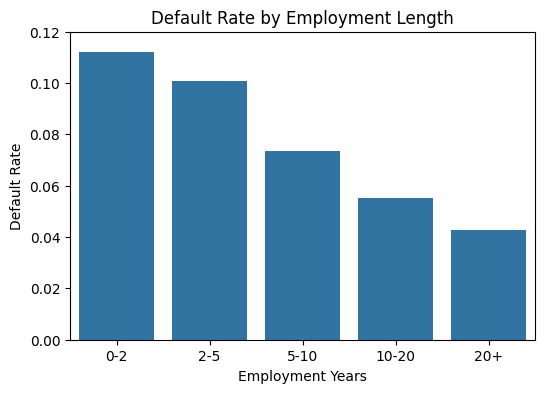

In [40]:
plt.figure(figsize=(6,4))
sns.barplot(x=emp_default.index, y=emp_default.values)

plt.ylabel("Default Rate")
plt.xlabel("Employment Years")
plt.title("Default Rate by Employment Length")
plt.ylim(0, 0.12)
plt.show()

Applicants with shorter employment history exhibit significantly higher default rates. Clients with less than 2 years of employment show a default rate of 11.2%, compared to only 4.26% among those with more than 20 years of employment. This indicates employment stability is a strong predictor of repayment behavior.

## Income type

In [ ]:
app_data['NAME_INCOME_TYPE'].value_counts()

,count
NAME_INCOME_TYPE,
Working,158774
Commercial associate,71617
Pensioner,55362
State servant,21703
Unemployed,22
Student,18
Businessman,10
Maternity leave,5


Extreme small sample can be ignored

In [ ]:
income_type_default = app_data.groupby('NAME_INCOME_TYPE')['TARGET'].mean().sort_values(ascending=False)
income_type_default

,TARGET
NAME_INCOME_TYPE,
Maternity leave,0.400000
Unemployed,0.363636
Working,0.095885
Commercial associate,0.074843
State servant,0.057550
Pensioner,0.053864
Businessman,0.000000
Student,0.000000


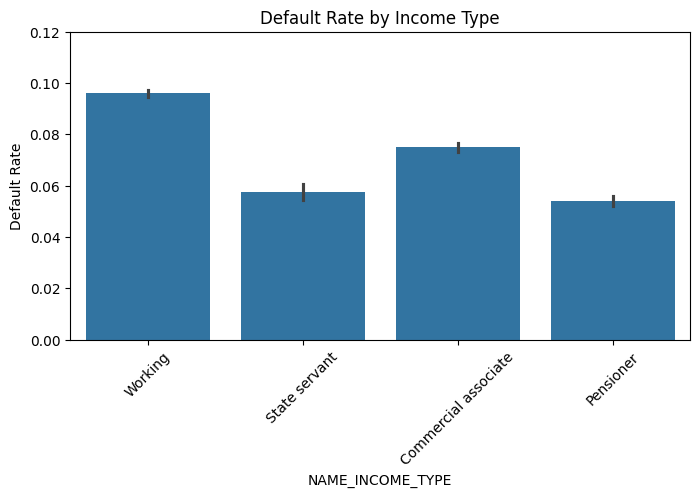

In [41]:
large_income = app_data['NAME_INCOME_TYPE'].value_counts()
large_income = large_income[large_income > 1000].index

income_plot = app_data[app_data['NAME_INCOME_TYPE'].isin(large_income)]

plt.figure(figsize=(8,4))
sns.barplot(x='NAME_INCOME_TYPE', y='TARGET', data=income_plot, estimator=np.mean)

plt.xticks(rotation=45)
plt.ylabel("Default Rate")
plt.title("Default Rate by Income Type")
plt.ylim(0, 0.12)
plt.show()

Among major income categories, applicants classified as “Working” exhibit the highest default rate (approximately 9.6%), followed by “Commercial associate” (7.5%), while “State servant” (5.8%) and “Pensioner” (5.4%) show significantly lower default rates. This pattern suggests that income stability plays an important role in repayment behavior, with more stable or institutional income sources associated with lower default risk.

## Education Level

In [43]:
app_data['NAME_EDUCATION_TYPE'].value_counts()

,count
NAME_EDUCATION_TYPE,
Secondary / secondary special,218391
Higher education,74863
Incomplete higher,10277
Lower secondary,3816
Academic degree,164


In [44]:
edu_default = app_data.groupby('NAME_EDUCATION_TYPE')['TARGET'].mean().sort_values(ascending=False)
edu_default

,TARGET
NAME_EDUCATION_TYPE,
Lower secondary,0.109277
Secondary / secondary special,0.089399
Incomplete higher,0.084850
Higher education,0.053551
Academic degree,0.018293


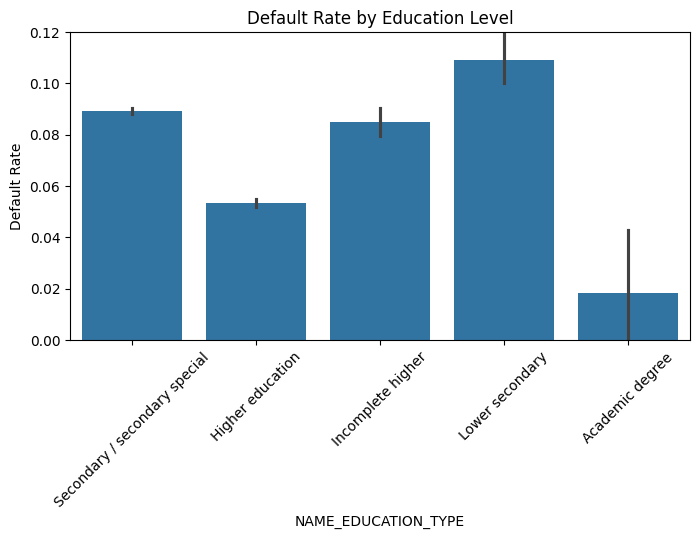

In [46]:
plt.figure(figsize=(8,4))

sns.barplot(x='NAME_EDUCATION_TYPE', y='TARGET', data=app_data, estimator=np.mean)

plt.xticks(rotation=45)
plt.ylabel("Default Rate")
plt.title("Default Rate by Education Level")
plt.ylim(0, 0.12)
plt.show()

Education level is strongly associated with default risk. Applicants with lower education levels exhibit significantly higher default rates, while those with higher education demonstrate substantially lower risk. For instance, clients with only lower secondary education show a default rate of approximately 10.9%, compared to 5.4% among those with higher education and just 1.8% for academic degree holders. This suggests that educational attainment is a strong predictor of repayment behavior and may reflect differences in income stability and financial resilience.

##Family status

In [ ]:
family_count = app_data['NAME_FAMILY_STATUS'].value_counts()
family_count

,count
NAME_FAMILY_STATUS,
Married,196432
Single / not married,45444
Civil marriage,29775
Separated,19770
Widow,16088
Unknown,2


In [ ]:
family_default = app_data.groupby('NAME_FAMILY_STATUS')['TARGET'].mean().sort_values(ascending=False)
family_default

,TARGET
NAME_FAMILY_STATUS,
Civil marriage,0.099446
Single / not married,0.098077
Separated,0.081942
Married,0.075599
Widow,0.058242
Unknown,0.000000


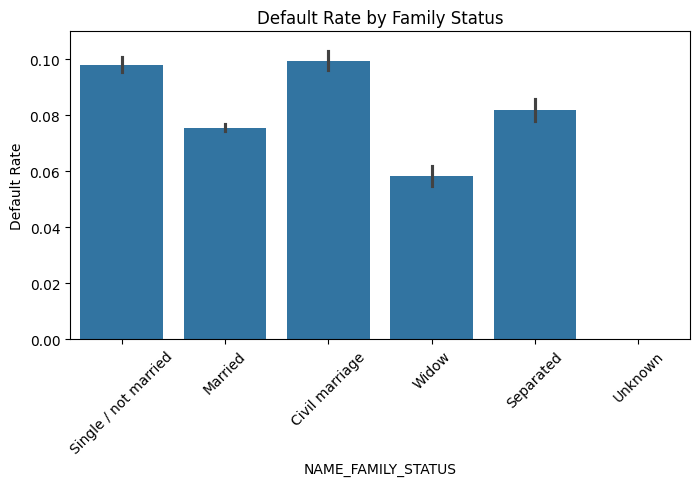

In [47]:
plt.figure(figsize=(8,4))
sns.barplot(x='NAME_FAMILY_STATUS', y='TARGET', data=app_data, estimator=np.mean)

plt.xticks(rotation=45)
plt.ylabel("Default Rate")
plt.title("Default Rate by Family Status")
plt.ylim(0, 0.11)
plt.show()

Family status is clearly associated with default risk. Applicants who are single or in civil marriages exhibit the highest default rates (around 9–10%), while married individuals show lower risk (7.6%), and widows demonstrate the lowest default rate (5.8%). This pattern suggests that greater household stability and social responsibility may be linked to stronger repayment behavior.

## Homeownership

In [ ]:
realty_count = app_data['FLAG_OWN_REALTY'].value_counts()
realty_count

,count
FLAG_OWN_REALTY,
Y,213312
N,94199


In [ ]:
realty_default = app_data.groupby('FLAG_OWN_REALTY')['TARGET'].mean()
realty_default

,TARGET
FLAG_OWN_REALTY,
N,0.083249
Y,0.079616


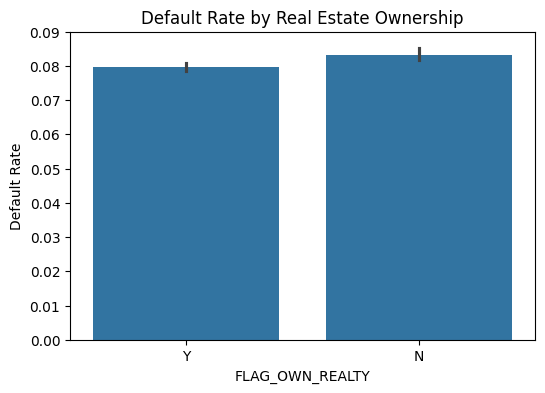

In [48]:
plt.figure(figsize=(6,4))

sns.barplot(x='FLAG_OWN_REALTY', y='TARGET', data=app_data, estimator=np.mean)

plt.ylabel("Default Rate")
plt.title("Default Rate by Real Estate Ownership")
plt.ylim(0, 0.09)
plt.show()

Homeownership is associated with lower default rates, but the effect is weak.

Compared to variables such as age, education, and years of work experience, homeownership is **not** a strong driving factor.

# Part2: analyze previous_application to extract "historical behavioral features".

In [51]:
prev_data.head()

,SK_ID_PREV,SK_ID_CURR,NAME_CONTRACT_TYPE,AMT_ANNUITY,AMT_APPLICATION,AMT_CREDIT,AMT_DOWN_PAYMENT,AMT_GOODS_PRICE,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,...,NAME_SELLER_INDUSTRY,CNT_PAYMENT,NAME_YIELD_GROUP,PRODUCT_COMBINATION,DAYS_FIRST_DRAWING,DAYS_FIRST_DUE,DAYS_LAST_DUE_1ST_VERSION,DAYS_LAST_DUE,DAYS_TERMINATION,NFLAG_INSURED_ON_APPROVAL
0,2030495,271877,Consumer loans,1730.430,17145.0,17145.0,0.0,17145.0,SATURDAY,15,...,Connectivity,12.0,middle,POS mobile with interest,365243.0,-42.0,300.0,-42.0,-37.0,0.0
1,2802425,108129,Cash loans,25188.615,607500.0,679671.0,NaN,607500.0,THURSDAY,11,...,XNA,36.0,low_action,Cash X-Sell: low,365243.0,-134.0,916.0,365243.0,365243.0,1.0
2,2523466,122040,Cash loans,15060.735,112500.0,136444.5,NaN,112500.0,TUESDAY,11,...,XNA,12.0,high,Cash X-Sell: high,365243.0,-271.0,59.0,365243.0,365243.0,1.0
3,2819243,176158,Cash loans,47041.335,450000.0,470790.0,NaN,450000.0,MONDAY,7,...,XNA,12.0,middle,Cash X-Sell: middle,365243.0,-482.0,-152.0,-182.0,-177.0,1.0
4,1784265,202054,Cash loans,31924.395,337500.0,404055.0,NaN,337500.0,THURSDAY,9,...,XNA,24.0,high,Cash Street: high,NaN,NaN,NaN,NaN,NaN,NaN


In [66]:
prev_app_count = prev_data.groupby('SK_ID_CURR').size().reset_index(name='PREV_APP_COUNT')

prev_refused = prev_data[prev_data['NAME_CONTRACT_STATUS'] == 'Refused'].groupby('SK_ID_CURR').size().reset_index(name='PREV_REFUSED_COUNT')

prev_approved = prev_data[prev_data['NAME_CONTRACT_STATUS'] == 'Approved'].groupby('SK_ID_CURR').size().reset_index(name='PREV_APPROVED_COUNT')

In [67]:
prev_features = prev_app_count.merge(prev_refused, on='SK_ID_CURR', how='left').merge(prev_approved, on='SK_ID_CURR', how='left')

prev_features = prev_features.fillna(0)

In [68]:
prev_features['PREV_REFUSED_RATIO'] = (prev_features['PREV_REFUSED_COUNT'] / prev_features['PREV_APP_COUNT'])

In [79]:
# Prevent exsiting data in previous merge
prev_cols = ['PREV_APP_COUNT', 'PREV_REFUSED_COUNT', 'PREV_APPROVED_COUNT', 'PREV_REFUSED_RATIO']
existing = [c for c in prev_cols if c in app_data.columns]

if existing:
    app_data = app_data.drop(columns=existing)

app_data = pd.merge(app_data, prev_features, on='SK_ID_CURR', how='left')

cols = ['PREV_APP_COUNT', 'PREV_REFUSED_COUNT', 'PREV_APPROVED_COUNT', 'PREV_REFUSED_RATIO']
app_data[cols] = app_data[cols].fillna(0)

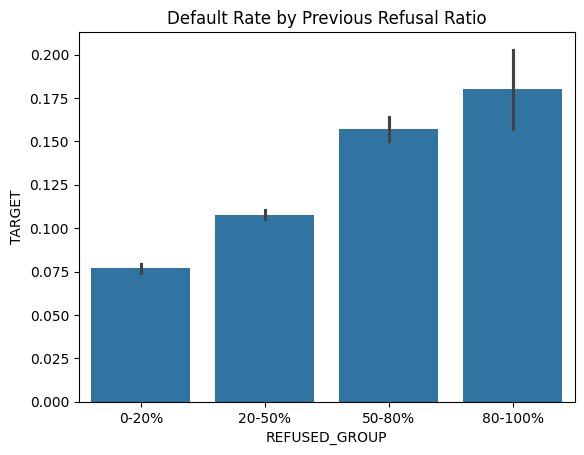

In [82]:
app_data['REFUSED_GROUP'] = pd.cut(
    app_data['PREV_REFUSED_RATIO'],
    bins=[0,0.2,0.5,0.8,1],
    labels=['0-20%','20-50%','50-80%','80-100%']
)

sns.barplot(x='REFUSED_GROUP', y='TARGET', data=app_data, estimator=np.mean)

plt.title("Default Rate by Previous Refusal Ratio")
plt.show()

Previous refusal history shows a strong and monotonic relationship with current default risk. As the ratio of previously refused applications increases, the default rate rises substantially—from about 7–8% for clients with less than 20% refusal history to nearly 18% for those with 80–100% refusal rates. This clear upward trend indicates that prior rejection behavior is a powerful predictor of future repayment difficulties and represents one of the strongest behavioral risk signals identified in the analysis.